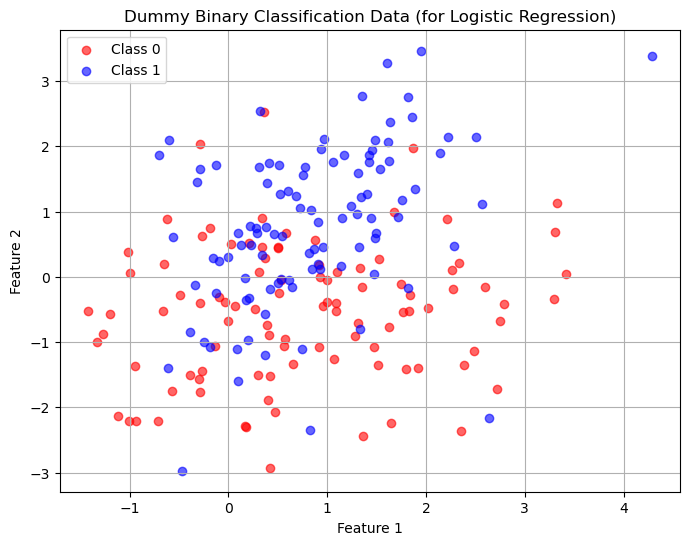

Features shape: (200, 2)
Target shape: (200,)


In [148]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [149]:
y=y.reshape(-1,1)
y.shape

(200, 1)

In [150]:
#initialization of centroids
kk=2

#centroid-index
centroid=[]
random_list=list(range(0,x.shape[0]))

#getting centroids
while(len(centroid)!=kk):
    random=np.random.choice(random_list)
    if random not in centroid:
        centroid.append(random)  

#actual k centroids
k=x[centroid]
print(k)

distance_history=[]

for epochs in range(1000):
    print(epochs)
    his={}
    k_curr=np.zeros((kk,x.shape[1]))
    for i in range(kk):
        his[i]=[]
    
    for i in range(x.shape[0]):
        difference=x[i]-k
        distance=np.sqrt(np.sum((difference**2),axis=1))
        distance_history.append(distance)
    
        min_distance=np.argmin(distance)
        #print(min_distance)
    
        his[min_distance].append(i)
    
    for i in range(kk):
        k_curr[i]=np.mean(x[his[i]],axis=0,keepdims=True)

    if np.all(k==k_curr):
        break

    else:
        k=k_curr
    

[[ 0.96106038 -0.44061899]
 [ 0.12321218  0.48115929]]
0
1
2
3
4
5
6
7
8


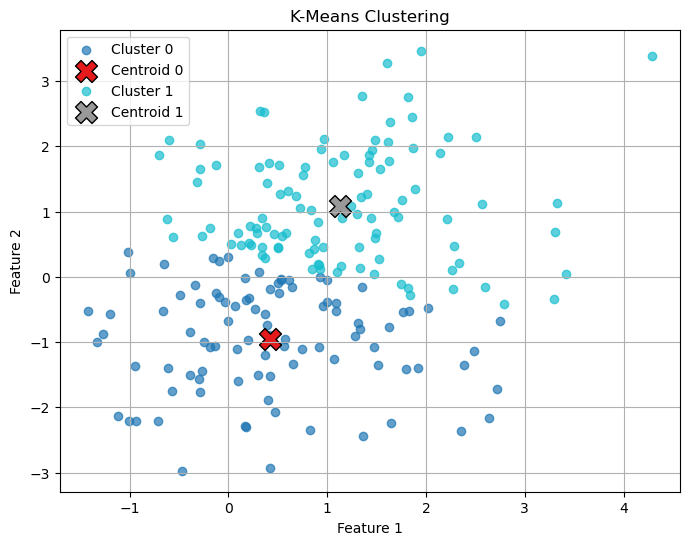

In [151]:
plt.figure(figsize=(8,6))

# Colors for clusters
cluster_colors = plt.cm.tab10(np.linspace(0, 1, kk))

# Colors for centroids (different colormap)
centroid_colors = plt.cm.Set1(np.linspace(0, 1, kk))

for i in range(kk):
    # Plot cluster points
    plt.scatter(
        x[his[i], 0],
        x[his[i], 1],
        color=cluster_colors[i],
        label=f"Cluster {i}",
        alpha=0.7
    )

    # Plot centroid
    plt.scatter(
        k[i, 0],
        k[i, 1],
        color=centroid_colors[i],
        marker='X',
        s=250,
        edgecolors='black',
        label=f"Centroid {i}"
    )

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()